In [2]:
import pandas as pd 
import numpy as np 
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller

In [3]:
#use this to install whatever other modules
#!pip install statsmodels
#!pip install yfinance

In [4]:
import sys
import yfinance as yf

print(sys.version)
print(yf.__version__)

3.12.2 | packaged by Anaconda, Inc. | (main, Feb 27 2024, 12:57:28) [Clang 14.0.6 ]
1.4.1


In [6]:
prices = yf.download(["KO", "PEP"], auto_adjust=True, start="2015-01-01", end="2022-01-01")
prices.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker             KO        PEP         KO        PEP         KO        PEP   
Date                                                                           
2015-01-02  29.390251  66.582947  29.571588  67.217469  29.153120  66.307986   
2015-01-05  29.390251  66.082344  29.969130  67.012982  29.348406  66.075292   
2015-01-06  29.613447  65.581795  29.948220  66.709845  29.460011  65.525397   
2015-01-07  29.983088  67.499458  30.066780  67.844926  29.697136  66.575872   
2015-01-08  30.345755  68.726234  30.387602  69.029397  30.059803  68.162209   

Price            Open               Volume           
Ticker             KO        PEP        KO      PEP  
Date                                                 
2015-01-02  29.473944  66.928410   9921100  3545700  
2015-01-05  29.773844  66.589960  26292600  6441000  
2015-01-06  29.578576  66.329129  16897500  6195000  
2015-01-07  29.850572  67.069390  13412300  6526300  
2015-01-08  30.115600  68.204509  21743600  7131600

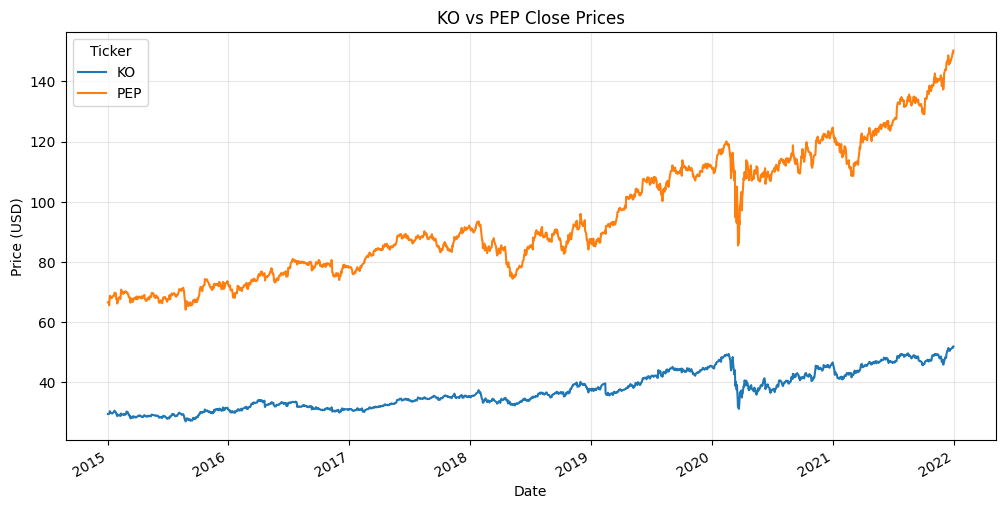

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

# Robustly extract 'Close' prices from the yfinance DataFrame (works with MultiIndex columns)
close = prices['Close']
# Pick KO and PEP if available
cols = [c for c in ['KO', 'PEP'] if c in close.columns]
ax = close[cols].plot(figsize=(12,6), title='KO vs PEP Close Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(alpha=0.3)
plt.show()
    

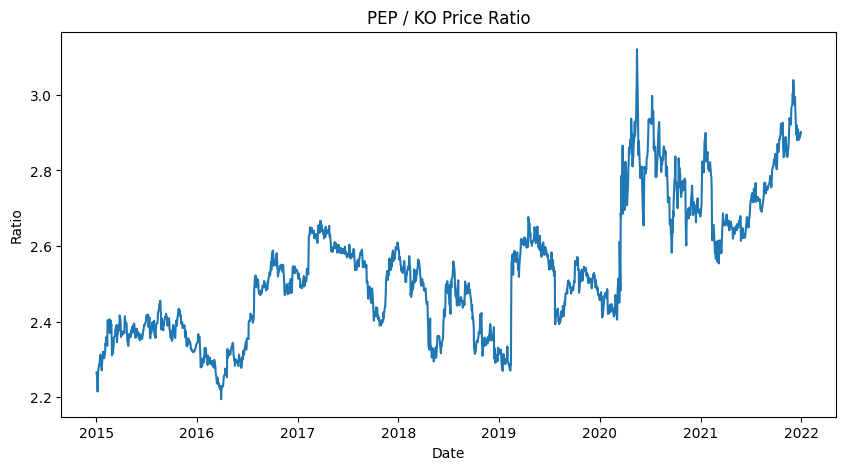

In [8]:
ratio = prices['Close']['PEP'] / prices['Close']['KO']
plt.figure(figsize=(10,5))
plt.plot(ratio)
plt.title("PEP / KO Price Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.show()

In [9]:
corr = prices["Close"]["PEP"].corr(prices["Close"]["KO"])
print(corr)

0.9619258455239347


## Cointegration Test
x_t and y_t are cointegrated, if x_t and y_t are I(1) series and there exists beta such that z_t = x_t - beta * y_t is an I(0) series

Meaning, individually they are x_t and y_t are non stationary but there is some linear combination of them which is stationary (mean reverting).

Cointegration describes a long-term relationship between two (or more) asset prices.
Cointegration can be viewed as a measure of similarity of assets in terms of risk exposure profiles.
The prices of cointegrated assets are tethered due to the stationarity of the spread.

From: https://hudsonthames.org/an-introduction-to-cointegration/

## cointegration and adfuller on raw close prices

In [10]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Step 1: regression
X = sm.add_constant(prices["Close"]["KO"]) #adds an intercept
model = sm.OLS(prices["Close"]["PEP"], X).fit() #runs least squares for regression

# Step 2: residuals
spread = model.resid

# Step 3: ADF test, a test to see if a time series is stationary (mean reverting)
adf_result = adfuller(spread)
print(adf_result[1])  # p-value

0.013000898598936977


## cointegration and ad fuller and spread construction on log prices

Engle-Granger coint test statistic: -3.5330
Engle-Granger p-value: 2.9580e-02
Critical values:
[-3.90266641 -3.3395999  -3.04685791]
Estimated alpha (log): 0.075369
Estimated beta (log): 1.236826
ADF statistic: -3.5319
ADF p-value for spread: 7.2036e-03
ADF critical values:
{'1%': -3.4340943816187823, '5%': -2.8631939359068803, '10%': -2.5676505066098376}


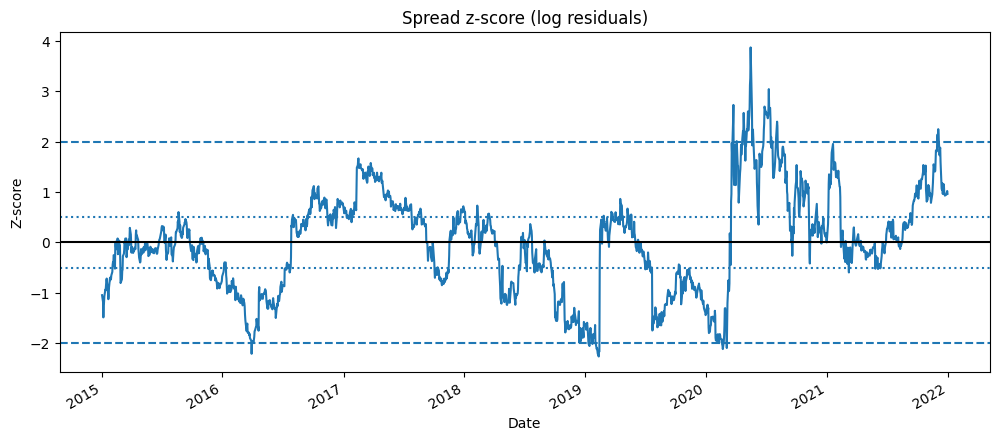

In [11]:
# --- Engle-Granger + spread construction + z-score ---

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
import matplotlib.pyplot as plt

# Use log prices
lp = np.log(prices["Close"])

# Engle-Granger cointegration test on log prices
c_stat, c_pvalue, c_crit = coint(lp["PEP"], lp["KO"])

print(f"Engle-Granger coint test statistic: {c_stat:.4f}")
print(f"Engle-Granger p-value: {c_pvalue:.4e}")
print("Critical values:")
print(c_crit)

# Regression on log prices: log(PEP) = alpha + beta * log(KO)
X_log = sm.add_constant(lp["KO"])
model_log = sm.OLS(lp["PEP"], X_log).fit()

alpha_log = model_log.params["const"]
beta_log = model_log.params["KO"]

print(f"Estimated alpha (log): {alpha_log:.6f}")
print(f"Estimated beta (log): {beta_log:.6f}")

# Construct spread using residuals
spread = model_log.resid

# ADF test on spread
adf_res = adfuller(spread)

print(f"ADF statistic: {adf_res[0]:.4f}")
print(f"ADF p-value for spread: {adf_res[1]:.4e}")
print("ADF critical values:")
print(adf_res[4])

# Z-score the spread
spread_z = (spread - spread.mean()) / spread.std()

# Plot spread z-score
plt.figure(figsize=(12, 5))
spread_z.plot(title="Spread z-score (log residuals)")
plt.axhline(0, color="black")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0.5, linestyle=":")
plt.axhline(-0.5, linestyle=":")
plt.ylabel("Z-score")
plt.show()